# Phase 2 — Unsupervised Learning
**Goal:** Discover natural patient groups using K-Means clustering, validate with DBSCAN, visualize with PCA, and add cluster labels as a feature for Phase 3.

## 1. Imports

In [287]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from imblearn.over_sampling import SMOTE

## 2. Load & Encode Data

In [274]:
# load cleaned data from Phase 1
df = pd.read_csv('../data/processed/heart_cleaned.csv')

# binary columns — label encode
df['sex'] = LabelEncoder().fit_transform(df['sex'])
df['fbs'] = df['fbs'].astype(int)
df['exang'] = df['exang'].astype(int)

# multi-category columns — one hot encode
df_encoded = pd.get_dummies(
    df,
    columns=['dataset', 'cp', 'restecg', 'slope'],
    dtype=int
)

print(f'Shape after encoding: {df_encoded.shape}')
print(df_encoded.dtypes)

Shape after encoding: (919, 23)
age                           int64
sex                           int64
trestbps                    float64
chol                        float64
fbs                           int64
thalch                      float64
exang                         int64
oldpeak                     float64
num                           int64
dataset_Cleveland             int64
dataset_Hungary               int64
dataset_Switzerland           int64
dataset_VA Long Beach         int64
cp_asymptomatic               int64
cp_atypical angina            int64
cp_non-anginal                int64
cp_typical angina             int64
restecg_lv hypertrophy        int64
restecg_normal                int64
restecg_st-t abnormality      int64
slope_downsloping             int64
slope_flat                    int64
slope_upsloping               int64
dtype: object


## 3. Separate Features & Target

In [275]:
X = df_encoded.drop(columns='num')
y = df_encoded['num']

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

X shape: (919, 22)
y shape: (919,)


## 4. Train Test Split
Split before any scaling or clustering — test set must never influence decisions.

In [276]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # preserves class ratio in both splits
)

print(f'X_train: {X_train.shape}')
print(f'X_test:  {X_test.shape}')
print(f'\ny_train class distribution:\n{y_train.value_counts()}')
print(f'\ny_test class distribution:\n{y_test.value_counts()}')

X_train: (735, 22)
X_test:  (184, 22)

y_train class distribution:
num
1    406
0    329
Name: count, dtype: int64

y_test class distribution:
num
1    102
0     82
Name: count, dtype: int64


## 5. Feature Scaling
K-Means uses distance — scaling is mandatory. Fit on train only, transform both.

In [277]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),   # transform only — never fit on test
    columns=X_test.columns
)

print('Scaling done.')
print(f'Mean of X_train_scaled (should be ~0): {X_train_scaled.mean().mean():.4f}')
print(f'Std  of X_train_scaled (should be ~1): {X_train_scaled.std().mean():.4f}')

Scaling done.
Mean of X_train_scaled (should be ~0): -0.0000
Std  of X_train_scaled (should be ~1): 0.9097


## 6. Find Optimal K — Elbow Method
Run K-Means for K=1 to 10 on training data only. Plot inertia to find the elbow.

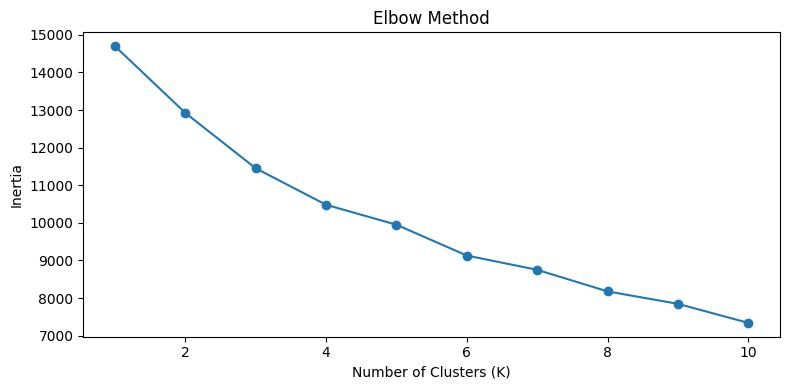

In [278]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_train_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.tight_layout()
plt.show()

## 7. Find Optimal K — Silhouette Score
Measures how well separated clusters are. Higher is better. Starts from K=2.

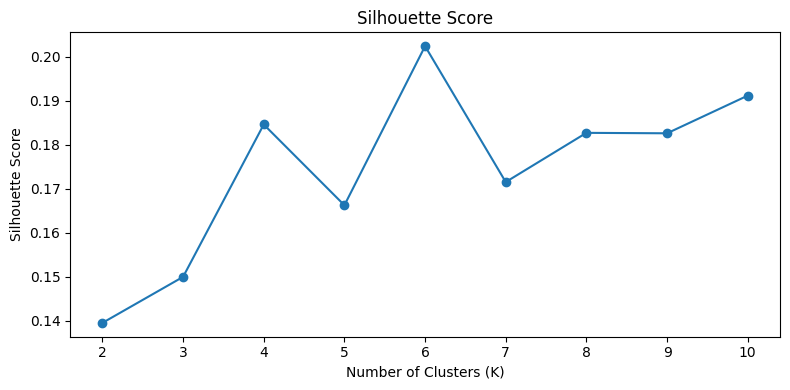

Best K by silhouette: 6


In [279]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_train_scaled)
    score = silhouette_score(X_train_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 4))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')
plt.tight_layout()
plt.show()

best_k = range(2, 11)[silhouette_scores.index(max(silhouette_scores))]
print(f'Best K by silhouette: {best_k}')

## 8. Train Final K-Means Model (K=3)
Elbow suggests K=3. K=3 is also interpretable — 3 clear patient profiles.

In [280]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_train_scaled)

# predict cluster labels for both splits
train_cluster_labels = kmeans.predict(X_train_scaled)
test_cluster_labels  = kmeans.predict(X_test_scaled)

print('Cluster distribution (train):')
print(pd.Series(train_cluster_labels).value_counts().sort_index())

Cluster distribution (train):
0    271
1    235
2    229
Name: count, dtype: int64


## 9. Interpret Clusters
What kind of patients are in each cluster? Add num temporarily to check disease rate.

In [281]:
# add labels temporarily for analysis only
X_train_scaled['cluster'] = train_cluster_labels
X_train_scaled['num']     = y_train.values

# average feature values per cluster (scaled)
print('Average feature values per cluster (scaled):')
print(X_train_scaled.groupby('cluster')[['age', 'thalch', 'oldpeak', 'trestbps', 'chol']].mean().round(2))

# disease rate per cluster
print('\nDisease rate per cluster (0=healthy, 1=disease):')
print(X_train_scaled.groupby('cluster')['num'].mean().round(2))

Average feature values per cluster (scaled):
          age  thalch  oldpeak  trestbps  chol
cluster                                       
0        0.49   -0.55     0.15      0.03 -0.12
1        0.04    0.59     0.10     -0.04  0.07
2       -0.62    0.05    -0.28      0.00  0.07

Disease rate per cluster (0=healthy, 1=disease):
cluster
0    0.82
1    0.43
2    0.36
Name: num, dtype: float64


## 10. PCA Visualization
Compress 22 features to 2 dimensions to visually inspect cluster separation.

Variance explained by PC1 + PC2: 30.16%


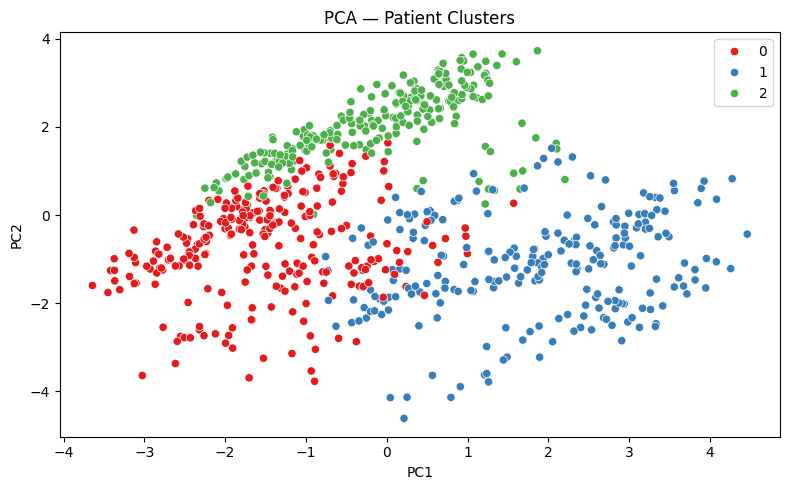

In [282]:
# drop analysis columns before PCA
X_for_pca = X_train_scaled.drop(columns=['cluster', 'num'])

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_for_pca)

print(f'Variance explained by PC1 + PC2: {pca.explained_variance_ratio_.sum():.2%}')

plt.figure(figsize=(8, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=train_cluster_labels, palette='Set1')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA — Patient Clusters')
plt.tight_layout()
plt.show()

## 11. DBSCAN — Outlier Detection
DBSCAN finds clusters by density and labels outliers as -1. Used here to validate K-Means and identify anomalous patients.

In [283]:
X_for_dbscan = X_train_scaled.drop(columns=['cluster', 'num'])

dbscan = DBSCAN(eps=2.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_for_dbscan)

n_clusters  = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_outliers  = list(dbscan_labels).count(-1)

print(f'DBSCAN clusters found : {n_clusters}')
print(f'Outliers (-1)         : {n_outliers} ({n_outliers/len(dbscan_labels)*100:.1f}%)')
print(f'Label distribution    :\n{pd.Series(dbscan_labels).value_counts().sort_index()}')

DBSCAN clusters found : 32
Outliers (-1)         : 205 (27.9%)
Label distribution    :
-1     205
 0       8
 1      16
 2      23
 3      40
 4      62
 5       9
 6      60
 7      25
 8       7
 9      33
 10     38
 11     32
 12     16
 13      8
 14      9
 15     15
 16      7
 17      6
 18      8
 19      8
 20      5
 21     15
 22     12
 23      9
 24     14
 25      7
 26      8
 27      9
 28      6
 29      5
 30      5
 31      5
Name: count, dtype: int64


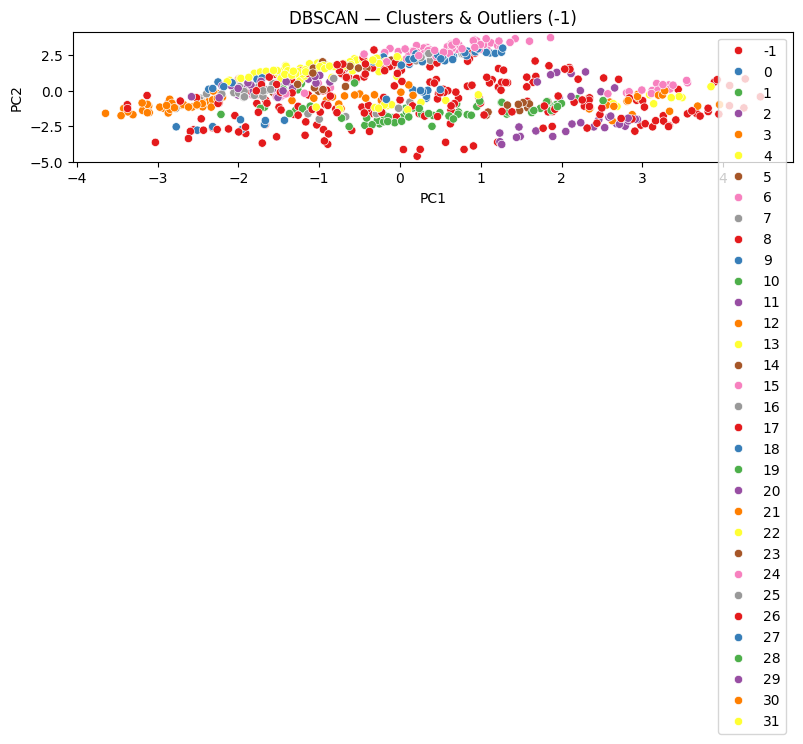

In [284]:
# visualize DBSCAN result on same PCA axes
plt.figure(figsize=(8, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=dbscan_labels, palette='Set1')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('DBSCAN — Clusters & Outliers (-1)')
plt.tight_layout()
plt.show()

## 12. Add Cluster Labels & Save
Add K-Means cluster label as a new feature to X_train and X_test. Save all splits for Phase 3.

In [285]:
# remove temporary analysis columns from scaled df
X_train_scaled = X_train_scaled.drop(columns=['cluster', 'num'])

# add cluster label to UNSCALED train and test
X_train['cluster'] = train_cluster_labels
X_test['cluster']  = test_cluster_labels

print(f'X_train shape: {X_train.shape}')  # should be (735, 23)
print(f'X_test  shape: {X_test.shape}')   # should be (184, 23)
print(f'\nX_train cluster distribution:\n{X_train["cluster"].value_counts().sort_index()}')

X_train shape: (735, 23)
X_test  shape: (184, 23)

X_train cluster distribution:
cluster
0    271
1    235
2    229
Name: count, dtype: int64


In [286]:
# save all splits to processed folder
X_train.to_csv('../data/processed/X_train.csv', index=False)
X_test.to_csv('../data/processed/X_test.csv',   index=False)
y_train.to_csv('../data/processed/y_train.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv',   index=False)

print('All files saved to data/processed/')
print('Phase 2 complete. Ready for Phase 3 — Supervised Learning.')

All files saved to data/processed/
Phase 2 complete. Ready for Phase 3 — Supervised Learning.
